XGBOOST on the kc_datadet for seattle house price 2014-2015

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
import plotly.express as px

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

df3 = pd.read_csv('Dataset 3.csv', engine='python')
print(df3.shape)

columns_to_drop = ['id', 'date', 'yr_renovated', 'zipcode', 'sqft_living15', 'sqft_lot15']
df3 = df3.drop(columns=[col for col in columns_to_drop if col in df3.columns])
print(df3.columns.tolist())
print(df3.shape)

df3.dropna(inplace=True)
target_column = 'price'
numerical_features = [col for col in df3.columns if col != target_column]
scaler = StandardScaler()
df3[numerical_features] = scaler.fit_transform(df3[numerical_features])
categorical_cols_to_encode = df3.select_dtypes(include='object').columns
df3 = pd.get_dummies(df3, columns=categorical_cols_to_encode, drop_first=True)
features = [col for col in df3.columns if col != target_column]
X = df3[features].copy()
y = df3[target_column].copy()
print("=" * 60)
print("DATASET 3")
print("=" * 60)

print("\nFirst 10 rows:")
display(df3.head(10))

print("\nData types:")
print(df3.dtypes)

print("\nMissing values:")
print(df3.isnull().sum())

print("\nTarget variable (price) statistics:")
print(df3['price'].describe())

(21613, 21)
['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'lat', 'long']
(21613, 15)
DATASET 3

First 10 rows:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,lat,long
0,221900.0,-0.398737,-1.447464,-0.979835,-0.228321,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.734708,-0.658681,-0.544898,-0.352572,-0.306079
1,538000.0,-0.398737,0.175607,0.533634,-0.189885,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.460841,0.245141,-0.681079,1.161568,-0.746341
2,180000.0,-1.473959,-1.447464,-1.426254,-0.123298,-0.915427,-0.087173,-0.305759,-0.629187,-1.409587,-1.229834,-0.658681,-1.293892,1.283537,-0.135655
3,604000.0,0.676485,1.149449,-0.130550,-0.244014,-0.915427,-0.087173,-0.305759,2.444294,-0.558836,-0.891699,1.397515,-0.204446,-0.283288,-1.271816
4,510000.0,-0.398737,-0.149007,-0.435422,-0.169653,-0.915427,-0.087173,-0.305759,-0.629187,0.291916,-0.130895,-0.658681,0.544548,0.409550,1.199335
5,1225000.0,0.676485,3.097133,3.636791,2.096185,-0.915427,-0.087173,-0.305759,-0.629187,2.844170,2.537955,2.798440,1.021181,0.693181,1.483375
6,257500.0,-0.398737,0.175607,-0.397313,-0.200098,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,-0.088628,-0.658681,0.816910,-1.806810,-0.803149
7,291850.0,-0.398737,-0.798235,-1.110494,-0.130276,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.879623,-0.658681,-0.272536,-1.086547,-0.717937
8,229500.0,-0.398737,-1.447464,-0.326539,-0.184381,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.891699,0.990795,-0.374672,-0.344633,-0.874160
9,323000.0,-0.398737,0.500221,-0.206768,-0.206351,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.122706,-0.658681,1.089271,-1.383168,1.298749



Data types:
price            float64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition        float64
grade            float64
sqft_above       float64
sqft_basement    float64
yr_built         float64
lat              float64
long             float64
dtype: object

Missing values:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
lat              0
long             0
dtype: int64

Target variable (price) statistics:
count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64


basic xgboost regressor model using a train-test split 80-20

In [4]:
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.model_selection import cross_validate
import numpy as np
import matplotlib.pyplot as plt
import sklearn

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model =XGBRegressor()
model.fit(X_train,y_train)
predictions = model.predict(X_test)

print("test validation")
print(" MSE", metrics.mean_squared_error(y_test,predictions))
print(" RMSE", metrics.root_mean_squared_error(y_test,predictions))
print(" r2", metrics.r2_score(y_test,predictions))

cv_results = cross_validate(model,X_train,y_train,cv=5,scoring=('neg_mean_squared_error','neg_root_mean_squared_error','r2'),return_train_score=True)

print("cross validation")
print(" MSE:",-cv_results['test_neg_mean_squared_error'].mean())
print(" RMSE",-cv_results['test_neg_root_mean_squared_error'].mean())
print(" r2",cv_results['test_r2'].mean())

test validation
 MSE 20317566713.175106
 RMSE 142539.7022347637
 r2 0.8656038591535542
cross validation
 MSE: 15369449533.46135
 RMSE 123631.6413185173
 r2 0.8828276340966162


#Results
Using the xgboost on the seattle housing dataset for 2014-2015, using a 80-20% train split with random sample, we observed the following results for prediction on the testing datset, a mean square error  20,317,566,713.18 , a root mean square error of 142, 539.70 and a R2 value of 0.86.

After cross evaluation, we observed a mean square error of  15,369,449,533.46, a root mean square error of 123,631.64, this shows a decrease in errors, along with a R2 value of 0.88, showing that the model preformed better on the entire dataset.

#Analysis
The large mean square error is due to errors of the predicted house prices being squared, causing it to "explode" into large values and thus we cannot use the mean square error for analysis, this can be mitigate by taking log of the price, causing the numbers to scale down but will have to be reversed. the root mean square error showed a error of 142, 539.70, meaning that the model's predicted price was generally off by 142, 539.70 compared to the actual price and the R2 value of 0.86 shows that the model can explain 86% of the variance of the dataset.

On the cross evalidation , we see that mean squared error and root mean squared error has been reduced and the r2 has increase with predictions off by  123,631.64 and the model explains 88% of the training set variance. this increase is to be expected as the model has seen the training data, the cross val use the k-fold seperates the training set into folds and rotates them.

Since the testing and cross val metrics are close, there is no indication of overfitting, that the model has memorised the data, from these test but is still posible that some relationships were memorised and the model has passed the threshold consider for underfitting generally above 50%, however the large RMSE values are a point of concern



 the model must perform slighty worse as a general function of the features and price by the testing, this may have indicative a minute memorizing but the drop is performance is expected and the drop of 0.02 is in the expected margin. The model overallly has a good fit, no indication major overfitting.

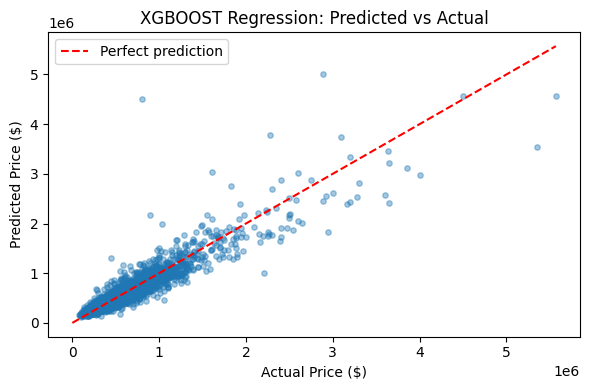

In [5]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, predictions, alpha=0.4, s=15)
max_val = max(y_test.max(), predictions.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('XGBOOST Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

From the graph of predicted value vs actual value, shows that most of the house prices range from  aproximatlly 100 000 to the 1.5 million dollars.After  house of the 1.5 to 2 million price range we see that the x=y line, prediction tends disperse away from the actual price,showing a great deal of struggling.The small and middle price range (below 1 million - 1.5 million) is where the model preformed  fairly well, but there is high amount of outliar prediction such as over prediction and under prediction. this means that the model is struggling with prediction of the higher values and also undestaninf the relationship between the house features and it price,which is endoursed by the large root mean squared errors.

In [6]:
importances =model.feature_importances_
print(importances)

feat_imp =pd.Series(importances,index=X_train.columns)
feat_imp_df =feat_imp.sort_values(ascending=True).reset_index()
feat_imp_df.columns =["Feature","Weight"]

fig = px.bar(
    feat_imp_df,
    x="Weight",
    y="Feature",
    orientation="h",
    title="Feature Importance (Weights)"
)
fig.show()




[0.00374494 0.0223712  0.10513395 0.0090198  0.00756968 0.2267957
 0.03370057 0.0071832  0.45642662 0.00940468 0.00742052 0.01983046
 0.05852173 0.03287696]


From the weight of the features from the weight vs feature graph, it is observed that the grade of the house with a weight of 0.45 has the most influence is the price of a house, with these weights totaling 1.0, the grade account for majoirty of the house price pridiction. this is followed by the waterfront feature which as 0.22, which is expected as generally waterfront propert is more costly due the views and other owner desires it provides. In third we have sqft_living which with a weight of 0.10 which is also expected, to be a higher indicaton of price,as more living space tend to mean a larger house and a higher price. These features of grade,waterfront,sqft_lving accounted for the majority of the prdiceted price with the remaining features having a significatly smaller influrence.

Some key observations were that latitude has a high preference for value that lognitude as house in the north and south are more desireable that those located in the east and west. Surprisingly features such as number of batherooms, bedrooms,condition and year built, number of floors had a combined total weight of 0.065, a very small influence as the house price can be predicted with out these features with of course some increase in errors, contridicting inital assumptions that these feature would have higher influence on the predicted price


#XGBOOST HYPERPARAMETER TUNING

while no suspision of overfitting, we will attempt to increase the preformance of the model with hyper parameter tuning using randomisedsearch and a 3 way split, train,test,evaluation split in a 70-15-15%. there was a suspsison that even though a random split was perform the train-test dataset from the previous model, that unequal distribution of the data in terms of price range such as high middle and lower were in the splits which can lead to the percetion of good performace and mask some model fitting issues. To mitigate this stafified randon sample was done where the stratied classes were the 20,40,60,80 percentiles and a 3 way split was done ensuring that each split had generally the same composition of house prices. the eval_data was also need to use the early_stopping_records where if there is little to no change between trees for the set number of trees the model stops the training prevent overfitting, this requires a evaluaton dataset, these testing set was used in this place. so that the eval would be unseen to the model for comparason with baseline

the model below is a baseline model for comparison before tuning

In [7]:
ytrain_bin =np.digitize(y,bins=np.percentile(y,[20,40,60,80]))
X_train1,X_test11,y_train1,y_test11=train_test_split(X,y,test_size=0.30,random_state=42,stratify=ytrain_bin)

ytest_bin =np.digitize(y_test11,bins=np.percentile(y,[20,40,60,80]))
X_test1,X_eval,y_test1,y_eval=train_test_split(X_test11,y_test11,test_size=0.50,random_state=42,stratify=ytest_bin)

baseline_model =XGBRegressor()
baseline_model.fit(X_train1,y_train1,verbose=True)

baseline_cv_results = cross_validate(baseline_model,X_train1,y_train1,cv=5,scoring=('neg_mean_squared_error','neg_root_mean_squared_error','r2'),return_train_score=True)
print("cross validation on training data")
print(" MSE:",-baseline_cv_results['test_neg_mean_squared_error'].mean())
print(" RMSE",-baseline_cv_results['test_neg_root_mean_squared_error'].mean())
print(" r2",baseline_cv_results['test_r2'].mean())

basedline_predict= baseline_model.predict(X_test1)
print("testing data")
print(" MSE", metrics.mean_squared_error(y_test1,basedline_predict))
print(" RMSE", metrics.root_mean_squared_error(y_test1,basedline_predict))
print(" r2", metrics.r2_score(y_test1,basedline_predict))

cross validation on training data
 MSE: 16966063655.562115
 RMSE 129590.75630600084
 r2 0.8762007174752615
testing data
 MSE 17557183834.638084
 RMSE 132503.5238574359
 r2 0.868847332413093


from the results, we see that performance is similar to the first model,in testing with a expected increase in RMSE from 129,590.75 to 132,503.52 and a decrease in the r2 value from 0.87 to 0.86. Due to the similar preformcance it can be concluded that there was little to no overfitting in the pervious model.

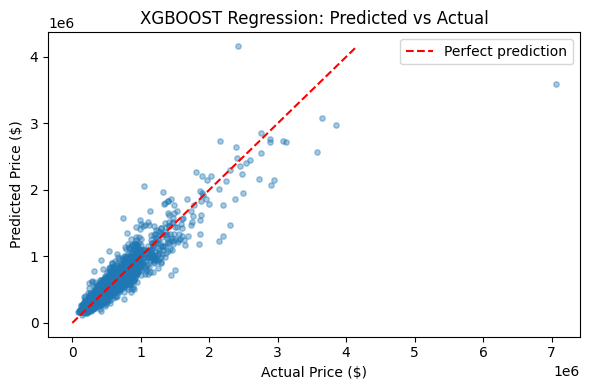

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(y_test1, basedline_predict, alpha=0.4, s=15)
max_val = max(y_eval.max(), basedline_predict.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('XGBOOST Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

from the graph of predicted vs actual price, the same story applies, after the 1.5 million price the model struggles with accurate prediction, with most of the house prices loacted in below the 1.5 millon price point. the model stills sturggles greatly in understanding the feature relationship with the higher price  displaying high variance with medium to high bias but has some understanding for the features relation to lower prices, displaying low bias with some medium variance in the prediction. the model performed well as the x=y line is generally centered in the dataset

In [9]:
importances = baseline_model.feature_importances_

print(importances)
feat_imp =pd.Series(importances,index=X_train.columns)
feat_imp_df =feat_imp.sort_values(ascending=True).reset_index()
feat_imp_df.columns = ["Feature","Weight"]

fig = px.bar(
    feat_imp_df,
    x="Weight",
    y="Feature",
    orientation="h",
    title="Feature Importance (Weights)"
)

fig.show()

[0.00248243 0.01849098 0.10065016 0.0078502  0.00419981 0.17904939
 0.04682264 0.00775008 0.4914138  0.01088427 0.00483102 0.02077608
 0.06452975 0.04026937]


we observered from the graph of weight vs features, that the weight of the feature grade increased from 0.45 to 0.49, with waterfront sqft_living and floors decreased in weight, while the other features had a slight increase in where condition weight exceed the first model's floor weight. this means in comparsion with the first model, the grade has more influence and all other features except for waterfront sqft_living and floors which mean that this model understandings slight differs as the first model had more emphasis on the waterfront and living space and floors to predict the price of the house

In [10]:
hp_model=XGBRegressor(early_stopping_rounds=16,random_state=42)
hyperparameter_grid = {
    'n_estimators': [100, 300, 600,650,625, 800],
    'max_depth': [3, 6, 4,7,5,2],
    'learning_rate': [0.01,0.08,0.3 ,0.03, 0.05,0.1],
    'reg_lambda': [2,2.5,5,10,12,7],
}

random_cv=sklearn.model_selection.RandomizedSearchCV(estimator=hp_model,
            param_distributions=hyperparameter_grid,
            cv=5,
            n_iter=100,
            scoring ='neg_root_mean_squared_error',
            n_jobs =-1,
            verbose=5,
            return_train_score=True,
            random_state=42)

random_cv.fit(X_train1,y_train1,eval_set=[(X_test1,y_test1)])
best_model= random_cv.best_estimator_
print(best_model.get_params())


best_pred= best_model.predict(X_test1)
print(" MSE", metrics.mean_squared_error(y_test1,best_pred))
print(" RMSE", metrics.root_mean_squared_error(y_test1,best_pred))
print(" r2", metrics.r2_score(y_test1,best_pred))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[0]	validation_0-rmse:346011.12168
[1]	validation_0-rmse:328158.70618
[2]	validation_0-rmse:312188.35151
[3]	validation_0-rmse:297382.43210
[4]	validation_0-rmse:284701.66727
[5]	validation_0-rmse:273017.61384
[6]	validation_0-rmse:262399.05826
[7]	validation_0-rmse:252347.54548
[8]	validation_0-rmse:244135.30575
[9]	validation_0-rmse:235384.69639
[10]	validation_0-rmse:227580.63568
[11]	validation_0-rmse:221360.47019
[12]	validation_0-rmse:215263.56326
[13]	validation_0-rmse:209830.32958
[14]	validation_0-rmse:204437.12158
[15]	validation_0-rmse:199915.64455
[16]	validation_0-rmse:196366.49940
[17]	validation_0-rmse:192767.13255
[18]	validation_0-rmse:189757.78061
[19]	validation_0-rmse:186879.45830
[20]	validation_0-rmse:184318.65165
[21]	validation_0-rmse:181899.33517
[22]	validation_0-rmse:179947.07002
[23]	validation_0-rmse:178106.27578
[24]	validation_0-rmse:176460.74381
[25]	validation_0-rmse:174948.20274
[26]	valida

as seem the from the 301 iteration the following 16 interaton were generlly bouncing back and forth around the same value so the search was stopped early. the best model parameters were learning rate = 0.08, max depth  =  5,n_estimators=650,reg_lambda =10.

this produced the results of MSE =19,692,488,488.93, RMSE= 140,329.92 and
 r2 =0.85. this RMSE value meaning that prediction were off by 140 329.92 dollare of the actual price and explains 85% of the variance in the test set which is slightly less than the baseline model

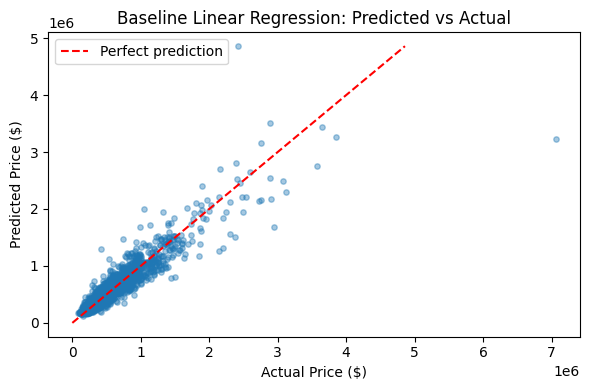

In [11]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test1, best_pred, alpha=0.4, s=15)
max_val = max(y_eval.max(), best_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Baseline Linear Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()


the graph of predicted vs actual is generally the same as the baseline model, as the hypertuned model still struggles in the same upper 1.5million price range, with the lower 1.5 million price range prediction being better but the model still preformed well fitting a general x=y line to the dataset

In [12]:
importances = best_model.feature_importances_

print(importances)
feat_imp =pd.Series(importances,index=X_train.columns)
feat_imp_df =feat_imp.sort_values(ascending=True).reset_index()
feat_imp_df.columns = ["Feature","Weight"]

fig = px.bar(
    feat_imp_df,
    x="Weight",
    y="Feature",
    orientation="h",
    title="Feature Importance (Weights)"
)

fig.show()

[0.00165358 0.01688838 0.1734178  0.00914903 0.00511471 0.12493113
 0.05662814 0.00923759 0.45533618 0.01315876 0.00418514 0.02588024
 0.06537234 0.03904705]


from the weight vs feature for the best model , we see that weights for grade has decreased from 0.49 to 0.45, sqft_living increased from 0.10 to 0.17, with condition increasing from 0.007 to 0.009, taking pritority over sqft_lot and floor increasing over sqft_basement. the remaining features all had a minor decrease in value but remaind in the same position. this shows that the tuning caused a slight alteration to the weights of the features to get the higher scores. in the tuned model , the living space has the second hightest weight and the number of batherooms is more valued than the number of bedrooms.

In [13]:
base_pred = baseline_model.predict(X_eval)
best_predict =best_model.predict(X_eval)

print("baseline model on evaluation data")
print(" MSE", metrics.mean_squared_error(y_eval,base_pred))
print(" RMSE", metrics.root_mean_squared_error(y_eval,base_pred))
print(" r2", metrics.r2_score(y_eval ,base_pred))

print("hyper tuning model on evaluation data")
print(" MSE", metrics.mean_squared_error(y_eval,best_predict))
print(" RMSE", metrics.root_mean_squared_error(y_eval,best_predict))
print(" r2", metrics.r2_score(y_eval ,best_predict))

baseline model on evaluation data
 MSE 16382219262.686832
 RMSE 127993.04380585233
 r2 0.8699777657222477
hyper tuning model on evaluation data
 MSE 15891349343.897726
 RMSE 126060.89537956537
 r2 0.8738736971926602


In the comparsion with the baseline and hyper tuned models on the evaluation set we observered that hypertuned performer slightly better with a rmse of 126,060.89 compared to 127,993.04 of the baseline, meaning that the hyper tuned was closer to the actual value and the hypertuned had a r2 of 0.87 against the baseline r2 of 0.86 meaning it explained a slight more of the variance of the evaulation dataset.

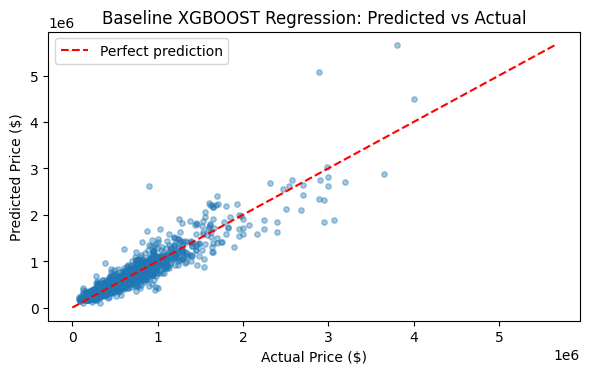

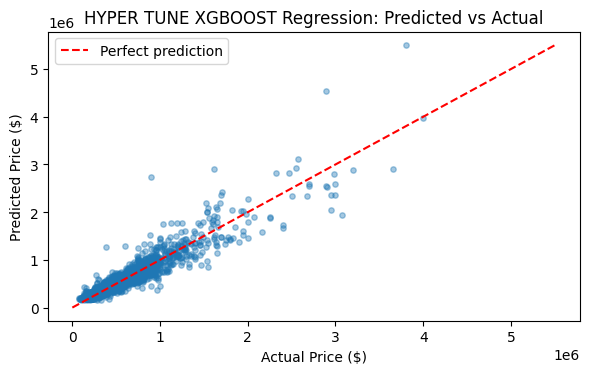

In [14]:
plt.figure(figsize=(6,4))
plt.scatter(y_eval, base_pred, alpha=0.4, s=15)
max_val = max(y_eval.max(), base_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Baseline XGBOOST Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(y_eval, best_predict, alpha=0.4, s=15)
max_val = max(y_eval.max(), best_predict.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('HYPER TUNE XGBOOST Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

while both struggle with the higher priced houses, we observed that the hyper tuned had slightly lower bias and lower variance with the lower sub 1 million price prediction however,the overall conclsusion is the both preform roughly the same, with slight improvement to the hyperparameter model. Overall the XGBoost model perform very well in general however , impoervments to the upper range of house price is needed as it it the major shortcomming of the model.